# 推荐模型（2017-2020 综合交互权重版）

本 Notebook 使用 `feature_engineering.ipynb` 生成的特征产物：

1. `book_tfidf_matrix.npz`：图书内容 TF-IDF 矩阵。
2. `books_info.pkl`：图书元数据映射表。
3. `user_item_weights.pkl`：用户-图书交互权重矩阵。

`INTEREST_WEIGHT` 当前采用“弱化时间”综合交互价值：

- 时间衰减权重：0.15
- 题名 TF-IDF 均值：0.30
- 主题词 TF-IDF 均值：0.25
- 图书总被借阅频次：0.20
- 用户总借阅频次：0.10

推荐模型采用混合策略：`Hybrid Score = α * Content-Based + (1 - α) * Collaborative Filtering`。


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity


def pick_chinese_font():
    preferred = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Source Han Sans SC', 'WenQuanYi Zen Hei']
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in preferred:
        if name in available:
            return name
    return None


chosen_font = pick_chinese_font()
font_list = [chosen_font] if chosen_font else ['DejaVu Sans']
sns.set_theme(style='whitegrid', rc={'font.family': 'sans-serif', 'font.sans-serif': font_list, 'axes.unicode_minus': False})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = font_list
plt.rcParams['axes.unicode_minus'] = False


def resolve_feature_dir():
    candidates = [Path('data/features'), Path('../data/features')]
    for p in candidates:
        if (p / 'book_tfidf_matrix.npz').exists() and (p / 'books_info.pkl').exists() and (p / 'user_item_weights.pkl').exists():
            return p
    raise FileNotFoundError('未找到 data/features 或 ../data/features 下的特征工程产物')


features_dir = resolve_feature_dir()
print('features_dir =', features_dir)
print('font =', chosen_font if chosen_font else 'fallback: DejaVu Sans')


features_dir = ..\data\features
font = Microsoft YaHei


In [2]:
class CampusHybridRecommender:
    def __init__(self, hybrid_weight=0.6, n_components=50):
        self.hybrid_weight = hybrid_weight
        self.n_components = n_components
        self.load_data()
        self.build_cf_model()

    def load_data(self):
        print('正在加载特征工程数据...')
        self.tfidf_matrix = sp.load_npz(features_dir / 'book_tfidf_matrix.npz')
        self.books_info = pd.read_pickle(features_dir / 'books_info.pkl')
        self.ui_weights = pd.read_pickle(features_dir / 'user_item_weights.pkl')

        self.books_info['TITLE'] = self.books_info['TITLE'].fillna('')
        self.book_id_to_idx = {book_id: idx for idx, book_id in enumerate(self.books_info['BOOK_ID'])}
        self.idx_to_book_id = {idx: book_id for book_id, idx in self.book_id_to_idx.items()}

        self.unique_users = self.ui_weights['USERID'].unique()
        self.user_id_to_idx = {user_id: idx for idx, user_id in enumerate(self.unique_users)}

        self.unique_titles = self.books_info['TITLE'].drop_duplicates().tolist()
        self.title_to_idx = {title: idx for idx, title in enumerate(self.unique_titles)}
        self.book_idx_to_title_idx = np.array([self.title_to_idx[title] for title in self.books_info['TITLE']])

        book_id_to_title = dict(zip(self.books_info['BOOK_ID'], self.books_info['TITLE']))
        self.ui_weights['TITLE_IDX'] = self.ui_weights['BOOK_ID'].map(lambda x: self.title_to_idx.get(book_id_to_title.get(x, ''), 0))

        print(f'数据加载完毕: {len(self.unique_users)} 名用户, {len(self.books_info)} 本图书, {len(self.unique_titles)} 个唯一书名。')
        print('INTEREST_WEIGHT 描述统计:')
        print(self.ui_weights['INTEREST_WEIGHT'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_string())

    def build_cf_model(self):
        print('正在构建协同过滤矩阵分解模型...')
        row_indices = [self.user_id_to_idx[u] for u in self.ui_weights['USERID']]
        col_indices = self.ui_weights['TITLE_IDX'].tolist()
        data = self.ui_weights['INTEREST_WEIGHT'].astype(float)

        self.ui_matrix = sp.csr_matrix(
            (data, (row_indices, col_indices)),
            shape=(len(self.unique_users), len(self.unique_titles))
        )

        max_components = max(1, min(self.ui_matrix.shape) - 1)
        n_components = min(self.n_components, max_components)
        self.svd = TruncatedSVD(n_components=n_components, random_state=42)
        self.user_factors = self.svd.fit_transform(self.ui_matrix)
        self.item_factors = self.svd.components_.T
        print(f'协同过滤模型训练完成: n_components={n_components}, explained_variance={self.svd.explained_variance_ratio_.sum():.4f}')

    def get_content_based_scores(self, target_user_id):
        user_history = self.ui_weights[self.ui_weights['USERID'] == target_user_id]
        if user_history.empty:
            return np.zeros(len(self.books_info))

        top_history = user_history.sort_values(by='INTEREST_WEIGHT', ascending=False).drop_duplicates(subset=['TITLE_IDX']).head(3)
        book_indices = [self.book_id_to_idx[b] for b in top_history['BOOK_ID'] if b in self.book_id_to_idx]
        if not book_indices:
            return np.zeros(len(self.books_info))

        user_profile_vector = np.asarray(self.tfidf_matrix[book_indices].mean(axis=0))
        return cosine_similarity(user_profile_vector, self.tfidf_matrix).flatten()

    def get_collaborative_scores(self, target_user_id):
        if target_user_id not in self.user_id_to_idx:
            return np.zeros(len(self.books_info))

        u_idx = self.user_id_to_idx[target_user_id]
        cf_title_scores = np.dot(self.user_factors[u_idx], self.item_factors.T)
        cf_scores = cf_title_scores[self.book_idx_to_title_idx]

        if cf_scores.max() > cf_scores.min():
            cf_scores = (cf_scores - cf_scores.min()) / (cf_scores.max() - cf_scores.min())
        return cf_scores

    def recommend(self, target_user_id, top_n=10):
        if target_user_id not in self.user_id_to_idx:
            return []

        cb_scores = self.get_content_based_scores(target_user_id)
        cf_scores = self.get_collaborative_scores(target_user_id)
        hybrid_scores = self.hybrid_weight * cb_scores + (1 - self.hybrid_weight) * cf_scores

        user_history_ids = self.ui_weights[self.ui_weights['USERID'] == target_user_id]['BOOK_ID'].tolist()
        history_indices = [self.book_id_to_idx[b] for b in user_history_ids if b in self.book_id_to_idx]
        history_titles = set(self.books_info.iloc[history_indices]['TITLE'].tolist())

        recommended_indices = []
        seen_titles = set(history_titles)
        for idx in np.argsort(hybrid_scores)[::-1]:
            title = self.books_info.iloc[idx]['TITLE']
            if title and title not in seen_titles:
                recommended_indices.append(idx)
                seen_titles.add(title)
            if len(recommended_indices) >= top_n:
                break

        return pd.DataFrame([
            {
                'rank': rank + 1,
                'BOOK_ID': self.idx_to_book_id[idx],
                'TITLE': self.books_info.iloc[idx]['TITLE'],
                'hybrid_score': round(float(hybrid_scores[idx]), 6),
                'CALL_NO': self.books_info.iloc[idx].get('CALL_NO', ''),
            }
            for rank, idx in enumerate(recommended_indices)
        ])


In [3]:
system = CampusHybridRecommender(hybrid_weight=0.6, n_components=50)

sample_user = system.ui_weights.groupby('USERID')['BOOK_ID'].count().sort_values(ascending=False).index[0]
print('sample_user =', sample_user)
system.recommend(sample_user, top_n=10)


正在加载特征工程数据...
数据加载完毕: 19706 名用户, 110931 本图书, 60211 个唯一书名。
INTEREST_WEIGHT 描述统计:
count    255188.000000
mean          0.058422
std           0.037473
min           0.000000
1%            0.020997
5%            0.025948
25%           0.038090
50%           0.050991
75%           0.065931
95%           0.124434
99%           0.212255
max           1.000000
正在构建协同过滤矩阵分解模型...
协同过滤模型训练完成: n_components=50, explained_variance=0.1003
sample_user = 1bfb522e67167020cf4d499983d32de2


,rank,BOOK_ID,TITLE,hybrid_score,CALL_NO
0,1,6CA0864A304D4394A2B1426E4C85FC0C,女神一号,0.559929,I247.57/1929
1,2,E698883D1FB547B3B0BD29369FD43E47,"鹿门歌.下,风波骤起",0.559342,I247.57/3110/3
2,3,B31868D95A284FD693EC237F9DD0CE28,"鹿门歌.上,滇云诡事",0.559342,I247.57/3110
3,4,0501504918C2493485A3F9EF1A3A0A03,"鹿门歌.中,千山叠影",0.559342,I247.57/3110/2
4,5,5ADE475794C24C49A3196159C9AAFC20,毕业,0.451343,I313.45/282
5,6,741C31AB78D745308A3264C72D76E156,圣女的救济,0.449798,I313.45/414
6,7,60F05B83D9074FC5B433AF9A1A9F7F6B,谁杀了她,0.448901,I313.45/216
7,8,3023384970A64CAAAAFD74E9D6C1A74E,湖畔,0.447827,I313.45/437
8,9,190AC822430140399D32D9C086E5BDE4,祈祷落幕时,0.446320,I313.45/346
9,10,6DFCD858FA6048C49D180E79AB001F2C,拉普拉斯的魔女,0.446271,I313.45/389


## 机器学习改进：BPR-MF + 二阶段精排

本节在原有推荐模型基础上增加 BPR-MF 和机器学习精排模型。

新增模型说明：
- `BPR-MF`：面向隐式反馈 Top-K 推荐的个性化排序矩阵分解。
- `ML-Ranker`：使用 LightGBM 的 `LGBMRanker`，基于候选召回分数与统计特征训练二阶段精排模型。

评估设置：
- 每个评估用户按 `LEND_DATE` 排序，最后 20% 唯一书名作为测试集。
- 训练矩阵使用非评估用户的完整历史 + 评估用户的训练历史，避免只用抽样用户训练 CF。
- 基于 `TITLE_IDX` 做去重，避免同一书名多册副本影响命中。
- 对比 Popularity、User-CF、Item-CF、SVD-CF、BPR-MF、Content-Based、Hybrid 和 ML-Ranker。
- 对 Hybrid 搜索 alpha，选择验证集表现最好的组合。


--- 严格 Top-10 推荐效果评估：BPR-MF + 机器学习精排 ---
BPR-MF epoch 1/2 完成
BPR-MF epoch 2/2 完成
ML-Ranker fold 1/2 完成: train_users=150, holdout_users=150
ML-Ranker fold 2/2 完成: train_users=150, holdout_users=150


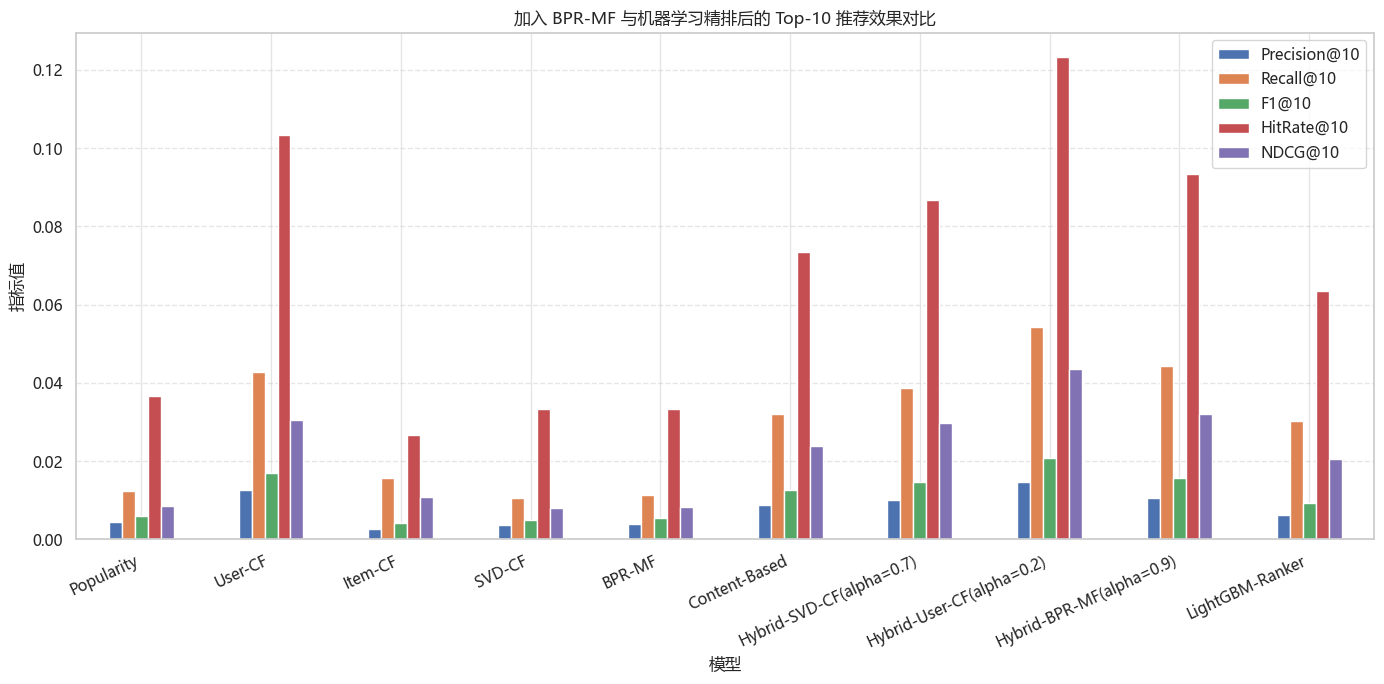

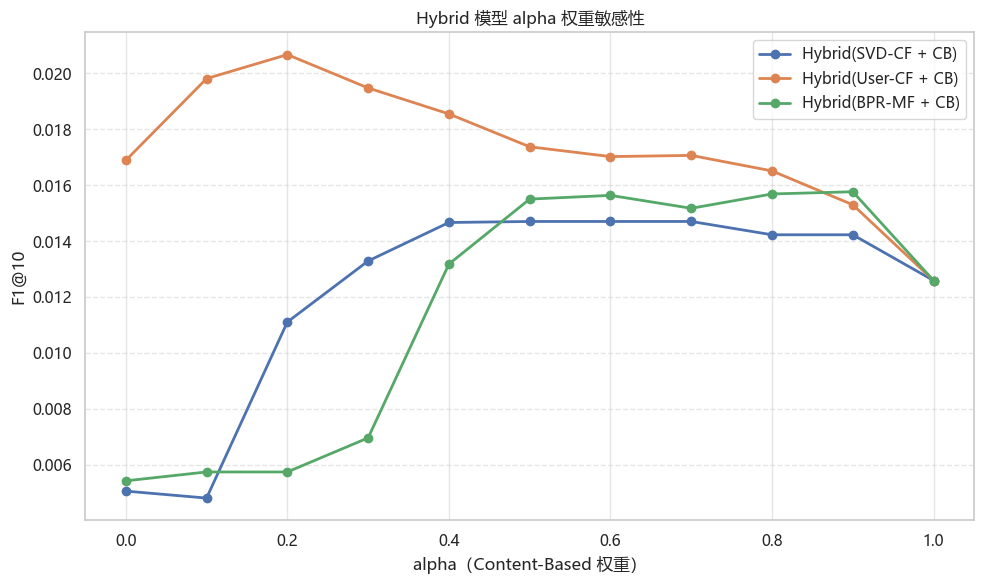

full train interactions: (247308, 3)
test interactions: (1069, 3)
ranker folds: 2 model eval users: 300
ranker train candidates: (73286, 13) positive labels: 1069
ranker backend: LightGBM-Ranker
saved: ..\data\features\model_comparison_results.csv
saved: ..\data\features\hybrid_weight_grid_results.csv
saved: ..\data\features\ml_ranker_train_candidates.csv
saved: ..\data\features\model_comparison_results.png
saved: ..\data\features\hybrid_weight_grid_results.png


,模型,Precision@10,Recall@10,F1@10,HitRate@10,NDCG@10,评估用户数
0,Popularity,0.004333,0.012472,0.005934,0.036667,0.008448,300
1,User-CF,0.012667,0.042664,0.016887,0.103333,0.030490,300
2,Item-CF,0.002667,0.015611,0.004252,0.026667,0.010727,300
3,SVD-CF,0.003667,0.010569,0.005054,0.033333,0.007992,300
4,BPR-MF,0.004000,0.011361,0.005421,0.033333,0.008358,300
5,Content-Based,0.008667,0.031963,0.012587,0.073333,0.023881,300
6,Hybrid-SVD-CF(alpha=0.7),0.010000,0.038630,0.014701,0.086667,0.029832,300
7,Hybrid-User-CF(alpha=0.2),0.014667,0.054335,0.020672,0.123333,0.043424,300
8,Hybrid-BPR-MF(alpha=0.9),0.010667,0.044324,0.015765,0.093333,0.032105,300
9,LightGBM-Ranker,0.006333,0.030321,0.009327,0.063333,0.020450,300


In [4]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from lightgbm import LGBMRanker

print('--- 严格 Top-10 推荐效果评估：BPR-MF + 机器学习精排 ---')

TOP_K = 10
EVAL_USER_LIMIT = 300
RANDOM_STATE = 42
HYBRID_WEIGHTS = np.round(np.arange(0.0, 1.01, 0.1), 2)
SIMILAR_USER_K = 80
CF_POPULARITY_FALLBACK = 0.05
BPR_FACTORS = 32
BPR_EPOCHS = 2
BPR_SAMPLES_PER_EPOCH = 60_000
RANKER_N_FOLDS = 2
CANDIDATES_PER_MODEL = 50
rng = np.random.default_rng(RANDOM_STATE)


def resolve_processed_dir():
    candidates = [Path('data/processed'), Path('../data/processed')]
    for p in candidates:
        if (p / 'users_2017_2020.csv').exists() and (p / 'books_2017_2020.csv').exists() and (p / 'borrows_2017_2020.csv').exists():
            return p
    raise FileNotFoundError('未找到处理后的三张表')


processed_dir = resolve_processed_dir()
users_df = pd.read_csv(processed_dir / 'users_2017_2020.csv', low_memory=False)
books_df = pd.read_csv(processed_dir / 'books_2017_2020.csv', low_memory=False)
borrows_df = pd.read_csv(processed_dir / 'borrows_2017_2020.csv', low_memory=False)
borrows_df['LEND_DATE'] = pd.to_datetime(borrows_df['LEND_DATE'], errors='coerce')

book_id_to_title = dict(zip(system.books_info['BOOK_ID'], system.books_info['TITLE']))
book_id_to_title_idx = {
    book_id: system.title_to_idx.get(title, 0)
    for book_id, title in book_id_to_title.items()
}

raw_all = borrows_df.dropna(subset=['USERID', 'BOOK_ID', 'LEND_DATE']).copy()
raw_all['TITLE_IDX'] = raw_all['BOOK_ID'].map(book_id_to_title_idx)
raw_all = raw_all.dropna(subset=['TITLE_IDX']).copy()
raw_all['TITLE_IDX'] = raw_all['TITLE_IDX'].astype(int)
raw_all = raw_all.sort_values('LEND_DATE')

active_users = raw_all.groupby('USERID')['TITLE_IDX'].nunique()
active_users = active_users[active_users >= 5].index.to_numpy()
eval_user_ids = rng.choice(active_users, size=min(EVAL_USER_LIMIT, len(active_users)), replace=False)
eval_user_set = set(eval_user_ids)

# 只对评估用户做留后验证；非评估用户保留完整历史作为协同过滤训练背景。
eval_raw = raw_all[raw_all['USERID'].isin(eval_user_set)].copy()
background_train_raw = raw_all[~raw_all['USERID'].isin(eval_user_set)].copy()

train_parts = []
test_parts = []
for user_id, group in eval_raw.groupby('USERID'):
    group = group.drop_duplicates(subset=['TITLE_IDX', 'LEND_DATE']).sort_values('LEND_DATE')
    unique_titles = group['TITLE_IDX'].drop_duplicates().tolist()
    if len(unique_titles) < 5:
        continue
    n_test = max(1, int(len(unique_titles) * 0.2))
    test_titles = set(unique_titles[-n_test:])
    test_group = group[group['TITLE_IDX'].isin(test_titles)]
    train_group = group[~group['TITLE_IDX'].isin(test_titles)]
    if not train_group.empty and not test_group.empty:
        train_parts.append(train_group)
        test_parts.append(test_group)

if not train_parts or not test_parts:
    raise ValueError('没有足够的评估用户可用于时间切分验证')

eval_train_raw = pd.concat(train_parts, ignore_index=True)
test_raw = pd.concat(test_parts, ignore_index=True)
eval_user_ids = np.array(sorted(set(eval_train_raw['USERID']) & set(test_raw['USERID'])))
train_raw = pd.concat([background_train_raw, eval_train_raw], ignore_index=True)

# 只使用训练数据重新构造弱化时间权重，避免评估阶段泄漏测试信息。
train_raw['USER_BASE_DATE'] = train_raw.groupby('USERID')['LEND_DATE'].transform('max')
train_raw['DAYS_AGO'] = (train_raw['USER_BASE_DATE'] - train_raw['LEND_DATE']).dt.days.clip(lower=0)
decay_lambda = np.log(2) / 180
train_raw['time_decay'] = np.exp(-decay_lambda * train_raw['DAYS_AGO'])
train_raw['user_title_count'] = train_raw.groupby('USERID')['TITLE_IDX'].transform('nunique')
train_raw['title_borrow_count'] = train_raw.groupby('TITLE_IDX')['USERID'].transform('count')

book_feature_lookup = system.books_info[['BOOK_ID', 'TITLE', 'SUB']].copy()
book_feature_lookup['TITLE'] = book_feature_lookup['TITLE'].fillna('')
book_feature_lookup['SUB'] = book_feature_lookup['SUB'].fillna('')
book_feature_lookup['title_len'] = book_feature_lookup['TITLE'].astype(str).str.len()
book_feature_lookup['subject_len'] = book_feature_lookup['SUB'].astype(str).str.len()
train_raw = train_raw.merge(book_feature_lookup[['BOOK_ID', 'title_len', 'subject_len']], on='BOOK_ID', how='left')

feature_cols_eval = ['user_title_count', 'title_borrow_count', 'time_decay', 'title_len', 'subject_len']
scaler_eval = MinMaxScaler()
X_eval = pd.DataFrame(scaler_eval.fit_transform(train_raw[feature_cols_eval].fillna(0)), columns=feature_cols_eval)

weak_time_weights_eval = {
    'time_decay': 0.15,
    'title_len': 0.30,
    'subject_len': 0.25,
    'title_borrow_count': 0.20,
    'user_title_count': 0.10,
}
train_raw['INTEREST_WEIGHT'] = sum(weak_time_weights_eval[col] * X_eval[col].values for col in feature_cols_eval)

train_eval = train_raw.groupby(['USERID', 'TITLE_IDX'], as_index=False)['INTEREST_WEIGHT'].sum()
train_weight_scaler = MinMaxScaler()
train_eval['INTEREST_WEIGHT'] = train_weight_scaler.fit_transform(train_eval[['INTEREST_WEIGHT']])
test_eval = test_raw.groupby(['USERID', 'TITLE_IDX'], as_index=False).size()

train_user_ids = train_eval['USERID'].unique()
train_user_id_to_idx = {user_id: idx for idx, user_id in enumerate(train_user_ids)}
row_indices = train_eval['USERID'].map(train_user_id_to_idx).to_numpy()
col_indices = train_eval['TITLE_IDX'].to_numpy()
data = train_eval['INTEREST_WEIGHT'].to_numpy(dtype=float)
train_matrix = sp.csr_matrix((data, (row_indices, col_indices)), shape=(len(train_user_ids), len(system.unique_titles)))
item_user_matrix = train_matrix.T.tocsr()
item_norms = np.sqrt(item_user_matrix.multiply(item_user_matrix).sum(axis=1)).A1

svd = TruncatedSVD(n_components=min(50, min(train_matrix.shape) - 1), random_state=42)
train_user_factors = svd.fit_transform(train_matrix)
train_item_factors = svd.components_.T

train_titles_by_user = train_eval.groupby('USERID')['TITLE_IDX'].apply(set).to_dict()
test_titles_by_user = test_eval.groupby('USERID')['TITLE_IDX'].apply(set).to_dict()

# 将图书级 TF-IDF 矩阵聚合为书名级矩阵，和评估使用的 TITLE_IDX 对齐。
title_rep_book_idx = {}
for book_idx, title_idx in enumerate(system.book_idx_to_title_idx):
    title_rep_book_idx.setdefault(title_idx, book_idx)
rep_indices = [title_rep_book_idx[i] for i in range(len(system.unique_titles))]
title_tfidf_matrix = system.tfidf_matrix[rep_indices]


def normalize_scores(scores):
    scores = np.asarray(scores, dtype=float).ravel()
    if scores.size == 0:
        return scores
    finite_mask = np.isfinite(scores)
    if not finite_mask.any():
        return np.zeros_like(scores)
    finite_scores = scores[finite_mask]
    result = np.zeros_like(scores, dtype=float)
    if finite_scores.max() > finite_scores.min():
        result[finite_mask] = (finite_scores - finite_scores.min()) / (finite_scores.max() - finite_scores.min())
    else:
        result[finite_mask] = finite_scores
    return result


train_popularity_scores = normalize_scores(np.asarray(train_matrix.sum(axis=0)).ravel())


def topk_from_scores(scores, exclude_titles, k=TOP_K):
    scores = np.asarray(scores, dtype=float).copy()
    if exclude_titles:
        scores[list(exclude_titles)] = -np.inf
    finite_count = int(np.isfinite(scores).sum())
    if finite_count == 0:
        return []
    k_eff = min(k, finite_count)
    top_idx = np.argpartition(scores, -k_eff)[-k_eff:]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
    return [int(i) for i in top_idx if np.isfinite(scores[i])][:k]


def content_scores_for_user(user_id):
    history = train_eval[train_eval['USERID'] == user_id].sort_values('INTEREST_WEIGHT', ascending=False).head(3)
    if history.empty:
        return np.zeros(len(system.unique_titles))
    title_indices = history['TITLE_IDX'].tolist()
    user_profile = np.asarray(title_tfidf_matrix[title_indices].mean(axis=0))
    return normalize_scores(cosine_similarity(user_profile, title_tfidf_matrix).ravel())


def svd_cf_scores_for_user(user_id):
    if user_id not in train_user_id_to_idx:
        return np.zeros(len(system.unique_titles))
    u_idx = train_user_id_to_idx[user_id]
    return normalize_scores(train_user_factors[u_idx] @ train_item_factors.T)


def item_cf_scores_for_user(user_id):
    history = train_eval[train_eval['USERID'] == user_id]
    if history.empty:
        return train_popularity_scores.copy()
    title_indices = history['TITLE_IDX'].to_numpy(dtype=int)
    history_weights = history['INTEREST_WEIGHT'].to_numpy(dtype=float)
    history_matrix = item_user_matrix[title_indices]
    profile_vec = history_matrix.T.dot(history_weights)
    profile_norm = np.linalg.norm(profile_vec)
    if profile_norm == 0:
        return train_popularity_scores.copy()
    raw_scores = item_user_matrix.dot(profile_vec)
    denom = item_norms * profile_norm
    cf_scores = np.divide(raw_scores, denom, out=np.zeros_like(raw_scores, dtype=float), where=denom > 0)
    cf_scores = normalize_scores(cf_scores)
    return normalize_scores((1 - CF_POPULARITY_FALLBACK) * cf_scores + CF_POPULARITY_FALLBACK * train_popularity_scores)


def user_cf_scores_for_user(user_id):
    if user_id not in train_user_id_to_idx:
        return train_popularity_scores.copy()
    u_idx = train_user_id_to_idx[user_id]
    sims = cosine_similarity(train_matrix[u_idx], train_matrix).ravel()
    sims[u_idx] = 0
    positive_idx = np.flatnonzero(sims > 0)
    if len(positive_idx) == 0:
        return train_popularity_scores.copy()
    if len(positive_idx) > SIMILAR_USER_K:
        top_users = positive_idx[np.argpartition(sims[positive_idx], -SIMILAR_USER_K)[-SIMILAR_USER_K:]]
    else:
        top_users = positive_idx
    top_sims = sims[top_users]
    cf_scores = np.asarray(top_sims @ train_matrix[top_users]).ravel()
    cf_scores = normalize_scores(cf_scores)
    return normalize_scores((1 - CF_POPULARITY_FALLBACK) * cf_scores + CF_POPULARITY_FALLBACK * train_popularity_scores)


class BPRMF:
    def __init__(self, n_users, n_items, item_prior=None, n_factors=32, learning_rate=0.04, reg=0.002, random_state=42):
        self.n_users = n_users
        self.n_items = n_items
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.reg = reg
        self.rng = np.random.default_rng(random_state)
        scale = 0.05
        self.user_factors = self.rng.normal(0, scale, size=(n_users, n_factors))
        self.item_factors = self.rng.normal(0, scale, size=(n_items, n_factors))
        if item_prior is None:
            self.item_bias = np.zeros(n_items, dtype=float)
        else:
            prior = normalize_scores(np.log1p(np.asarray(item_prior, dtype=float)))
            self.item_bias = 0.05 * prior

    def fit(self, matrix, epochs=2, samples_per_epoch=120_000):
        csr = matrix.tocsr()
        pos_items_by_user = []
        pos_sets_by_user = []
        active_users = []
        for u in range(self.n_users):
            items = csr.indices[csr.indptr[u]:csr.indptr[u + 1]]
            pos_items_by_user.append(items)
            pos_sets_by_user.append(set(items.tolist()))
            if len(items) > 0 and len(items) < self.n_items:
                active_users.append(u)
        active_users = np.array(active_users, dtype=int)
        if len(active_users) == 0:
            return self

        for epoch in range(epochs):
            for _ in range(samples_per_epoch):
                u = int(active_users[self.rng.integers(len(active_users))])
                pos_items = pos_items_by_user[u]
                i = int(pos_items[self.rng.integers(len(pos_items))])
                j = int(self.rng.integers(self.n_items))
                while j in pos_sets_by_user[u]:
                    j = int(self.rng.integers(self.n_items))

                u_vec = self.user_factors[u].copy()
                i_vec = self.item_factors[i].copy()
                j_vec = self.item_factors[j].copy()
                x_uij = float(u_vec @ (i_vec - j_vec) + self.item_bias[i] - self.item_bias[j])
                grad = 1.0 / (1.0 + np.exp(np.clip(x_uij, -35, 35)))

                self.user_factors[u] += self.learning_rate * (grad * (i_vec - j_vec) - self.reg * u_vec)
                self.item_factors[i] += self.learning_rate * (grad * u_vec - self.reg * i_vec)
                self.item_factors[j] += self.learning_rate * (-grad * u_vec - self.reg * j_vec)
                self.item_bias[i] += self.learning_rate * (grad - self.reg * self.item_bias[i])
                self.item_bias[j] += self.learning_rate * (-grad - self.reg * self.item_bias[j])
            print(f'BPR-MF epoch {epoch + 1}/{epochs} 完成')
        return self

    def scores(self, user_idx):
        return self.user_factors[user_idx] @ self.item_factors.T + self.item_bias


bpr = BPRMF(
    n_users=train_matrix.shape[0],
    n_items=train_matrix.shape[1],
    item_prior=np.asarray(train_matrix.sum(axis=0)).ravel(),
    n_factors=BPR_FACTORS,
    random_state=RANDOM_STATE,
)
bpr.fit(train_matrix, epochs=BPR_EPOCHS, samples_per_epoch=BPR_SAMPLES_PER_EPOCH)


def bpr_scores_for_user(user_id):
    if user_id not in train_user_id_to_idx:
        return train_popularity_scores.copy()
    u_idx = train_user_id_to_idx[user_id]
    return normalize_scores(bpr.scores(u_idx))


score_cache = {}


def get_score_bundle(user_id):
    if user_id not in score_cache:
        content = content_scores_for_user(user_id)
        svd_cf = svd_cf_scores_for_user(user_id)
        user_cf = user_cf_scores_for_user(user_id)
        item_cf = item_cf_scores_for_user(user_id)
        bpr_scores = bpr_scores_for_user(user_id)
        score_cache[user_id] = {
            'popularity': train_popularity_scores,
            'content': content,
            'svd_cf': svd_cf,
            'user_cf': user_cf,
            'item_cf': item_cf,
            'bpr': bpr_scores,
            'hybrid_svd': normalize_scores(0.6 * content + 0.4 * svd_cf),
            'hybrid_user': normalize_scores(0.7 * content + 0.3 * user_cf),
            'hybrid_bpr': normalize_scores(0.6 * content + 0.4 * bpr_scores),
        }
    return score_cache[user_id]


def candidate_titles_for_user(user_id, include_truth=False):
    exclude_titles = train_titles_by_user.get(user_id, set())
    truth = test_titles_by_user.get(user_id, set())
    bundle = get_score_bundle(user_id)
    candidates = set()
    for key in ['popularity', 'content', 'svd_cf', 'user_cf', 'item_cf', 'bpr', 'hybrid_svd', 'hybrid_user', 'hybrid_bpr']:
        candidates.update(topk_from_scores(bundle[key], exclude_titles, CANDIDATES_PER_MODEL))
    if include_truth:
        candidates.update(truth)
    candidates.difference_update(exclude_titles)
    return sorted(candidates)


def ranker_feature_rows(user_ids, include_truth=False):
    rows = []
    for user_id in user_ids:
        truth = test_titles_by_user.get(user_id, set())
        history_size = len(train_titles_by_user.get(user_id, set()))
        candidates = candidate_titles_for_user(user_id, include_truth=include_truth)
        bundle = get_score_bundle(user_id)
        for title_idx in candidates:
            rows.append({
                'USERID': user_id,
                'TITLE_IDX': int(title_idx),
                'popularity_score': float(bundle['popularity'][title_idx]),
                'content_score': float(bundle['content'][title_idx]),
                'svd_cf_score': float(bundle['svd_cf'][title_idx]),
                'user_cf_score': float(bundle['user_cf'][title_idx]),
                'item_cf_score': float(bundle['item_cf'][title_idx]),
                'bpr_score': float(bundle['bpr'][title_idx]),
                'hybrid_svd_score': float(bundle['hybrid_svd'][title_idx]),
                'hybrid_user_score': float(bundle['hybrid_user'][title_idx]),
                'hybrid_bpr_score': float(bundle['hybrid_bpr'][title_idx]),
                'user_history_size': history_size,
                'label': int(title_idx in truth),
            })
    return pd.DataFrame(rows)


ranker_feature_cols = [
    'popularity_score', 'content_score', 'svd_cf_score', 'user_cf_score', 'item_cf_score', 'bpr_score',
    'hybrid_svd_score', 'hybrid_user_score', 'hybrid_bpr_score', 'user_history_size'
]


def fit_ranker_model(train_df):
    if train_df.empty or train_df['label'].nunique() < 2:
        return None, 'ML-Ranker(训练标签不足)'
    backend_name = 'LightGBM-Ranker'
    train_df = train_df.sort_values('USERID')
    group_sizes = train_df.groupby('USERID').size().tolist()
    ranker = LGBMRanker(
        objective='lambdarank',
        n_estimators=80,
        learning_rate=0.05,
        num_leaves=31,
        random_state=RANDOM_STATE,
        verbose=-1,
    )
    ranker.fit(train_df[ranker_feature_cols], train_df['label'], group=group_sizes)
    return ranker, backend_name


def predict_ranker_scores(user_id, ranker):
    if ranker is None:
        return get_score_bundle(user_id)['hybrid_bpr']
    candidates = candidate_titles_for_user(user_id, include_truth=False)
    scores = np.full(len(system.unique_titles), -np.inf, dtype=float)
    if not candidates:
        return get_score_bundle(user_id)['hybrid_bpr']
    rows = []
    bundle = get_score_bundle(user_id)
    history_size = len(train_titles_by_user.get(user_id, set()))
    for title_idx in candidates:
        rows.append({
            'popularity_score': float(bundle['popularity'][title_idx]),
            'content_score': float(bundle['content'][title_idx]),
            'svd_cf_score': float(bundle['svd_cf'][title_idx]),
            'user_cf_score': float(bundle['user_cf'][title_idx]),
            'item_cf_score': float(bundle['item_cf'][title_idx]),
            'bpr_score': float(bundle['bpr'][title_idx]),
            'hybrid_svd_score': float(bundle['hybrid_svd'][title_idx]),
            'hybrid_user_score': float(bundle['hybrid_user'][title_idx]),
            'hybrid_bpr_score': float(bundle['hybrid_bpr'][title_idx]),
            'user_history_size': history_size,
        })
    feature_df = pd.DataFrame(rows)
    if hasattr(ranker, 'predict_proba'):
        pred = ranker.predict_proba(feature_df[ranker_feature_cols])[:, 1]
    else:
        pred = ranker.predict(feature_df[ranker_feature_cols])
    scores[candidates] = pred
    return scores


# 精排模型采用用户级交叉验证。每个评估用户都参与最终评估，但其精排分数由不包含该用户的折外模型给出。
shuffled_eval_users = np.array(eval_user_ids)
rng.shuffle(shuffled_eval_users)
fold_count = min(RANKER_N_FOLDS, len(shuffled_eval_users))
ranker_folds = [fold for fold in np.array_split(shuffled_eval_users, fold_count) if len(fold) > 0]
ranker_oof_scores = {}
ranker_train_frames = []
ranker_backend_names = []

for fold_idx, holdout_users in enumerate(ranker_folds, start=1):
    train_users = np.setdiff1d(shuffled_eval_users, holdout_users)
    fold_train_df = ranker_feature_rows(train_users, include_truth=True)
    ranker_train_frames.append(fold_train_df)
    fold_ranker, fold_backend_name = fit_ranker_model(fold_train_df)
    ranker_backend_names.append(fold_backend_name)
    for user_id in holdout_users:
        ranker_oof_scores[user_id] = predict_ranker_scores(user_id, fold_ranker)
    print(f'ML-Ranker fold {fold_idx}/{len(ranker_folds)} 完成: train_users={len(train_users)}, holdout_users={len(holdout_users)}')

ranker_train_df = pd.concat(ranker_train_frames, ignore_index=True)
ranker_backend_name = ranker_backend_names[0] if ranker_backend_names else 'ML-Ranker(未训练)'
model_eval_user_ids = eval_user_ids


def ml_ranker_scores_for_user(user_id):
    return ranker_oof_scores.get(user_id, get_score_bundle(user_id)['hybrid_bpr'])


def evaluate_model(model_name, score_func, user_ids=None):
    if user_ids is None:
        user_ids = model_eval_user_ids
    precisions, recalls, f1s, hit_rates, ndcgs = [], [], [], [], []
    for user_id in user_ids:
        truth = test_titles_by_user.get(user_id, set())
        if not truth:
            continue
        exclude_titles = train_titles_by_user.get(user_id, set())
        recs = topk_from_scores(score_func(user_id), exclude_titles, TOP_K)
        hits = len(set(recs) & truth)
        precision = hits / TOP_K
        recall = hits / len(truth)
        f1 = 0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
        dcg = sum(1 / np.log2(rank + 2) for rank, item in enumerate(recs) if item in truth)
        ideal_hits = min(len(truth), TOP_K)
        idcg = sum(1 / np.log2(rank + 2) for rank in range(ideal_hits))
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        hit_rates.append(float(hits > 0))
        ndcgs.append(0 if idcg == 0 else dcg / idcg)
    return {
        '模型': model_name,
        f'Precision@{TOP_K}': float(np.mean(precisions)),
        f'Recall@{TOP_K}': float(np.mean(recalls)),
        f'F1@{TOP_K}': float(np.mean(f1s)),
        f'HitRate@{TOP_K}': float(np.mean(hit_rates)),
        f'NDCG@{TOP_K}': float(np.mean(ndcgs)),
        '评估用户数': len(precisions),
    }


base_results = [
    evaluate_model('Popularity', lambda user_id: train_popularity_scores),
    evaluate_model('User-CF', user_cf_scores_for_user),
    evaluate_model('Item-CF', item_cf_scores_for_user),
    evaluate_model('SVD-CF', svd_cf_scores_for_user),
    evaluate_model('BPR-MF', bpr_scores_for_user),
    evaluate_model('Content-Based', content_scores_for_user),
]

hybrid_rows = []
for alpha in HYBRID_WEIGHTS:
    hybrid_rows.append(evaluate_model(
        f'Hybrid-SVD-CF(alpha={alpha:.1f})',
        lambda user_id, a=alpha: a * content_scores_for_user(user_id) + (1 - a) * svd_cf_scores_for_user(user_id)
    ))
    hybrid_rows.append(evaluate_model(
        f'Hybrid-User-CF(alpha={alpha:.1f})',
        lambda user_id, a=alpha: a * content_scores_for_user(user_id) + (1 - a) * user_cf_scores_for_user(user_id)
    ))
    hybrid_rows.append(evaluate_model(
        f'Hybrid-BPR-MF(alpha={alpha:.1f})',
        lambda user_id, a=alpha: a * content_scores_for_user(user_id) + (1 - a) * bpr_scores_for_user(user_id)
    ))

hybrid_grid_df = pd.DataFrame(hybrid_rows)
best_svd = hybrid_grid_df[hybrid_grid_df['模型'].str.startswith('Hybrid-SVD-CF')].sort_values(f'F1@{TOP_K}', ascending=False).head(1)
best_user = hybrid_grid_df[hybrid_grid_df['模型'].str.startswith('Hybrid-User-CF')].sort_values(f'F1@{TOP_K}', ascending=False).head(1)
best_bpr = hybrid_grid_df[hybrid_grid_df['模型'].str.startswith('Hybrid-BPR-MF')].sort_values(f'F1@{TOP_K}', ascending=False).head(1)
ml_result = pd.DataFrame([evaluate_model(ranker_backend_name, ml_ranker_scores_for_user)])
comparison_df = pd.concat([pd.DataFrame(base_results), best_svd, best_user, best_bpr, ml_result], ignore_index=True)

comparison_path = features_dir / 'model_comparison_results.csv'
grid_path = features_dir / 'hybrid_weight_grid_results.csv'
ranker_train_path = features_dir / 'ml_ranker_train_candidates.csv'
comparison_df.to_csv(comparison_path, index=False, encoding='utf-8-sig')
hybrid_grid_df.to_csv(grid_path, index=False, encoding='utf-8-sig')
ranker_train_df.to_csv(ranker_train_path, index=False, encoding='utf-8-sig')

metric_cols = [f'Precision@{TOP_K}', f'Recall@{TOP_K}', f'F1@{TOP_K}', f'HitRate@{TOP_K}', f'NDCG@{TOP_K}']
comparison_df.set_index('模型')[metric_cols].plot(kind='bar', figsize=(14, 7))
plt.title('加入 BPR-MF 与机器学习精排后的 Top-10 推荐效果对比')
plt.ylabel('指标值')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plot_path = features_dir / 'model_comparison_results.png'
plt.savefig(plot_path, dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
for model_prefix, label in [
    ('Hybrid-SVD-CF', 'Hybrid(SVD-CF + CB)'),
    ('Hybrid-User-CF', 'Hybrid(User-CF + CB)'),
    ('Hybrid-BPR-MF', 'Hybrid(BPR-MF + CB)'),
]:
    sub = hybrid_grid_df[hybrid_grid_df['模型'].str.startswith(model_prefix)].copy()
    sub['alpha'] = sub['模型'].str.extract(r'alpha=([0-9.]+)').astype(float)
    plt.plot(sub['alpha'], sub[f'F1@{TOP_K}'], marker='o', linewidth=2, label=label)
plt.title('Hybrid 模型 alpha 权重敏感性')
plt.xlabel('alpha（Content-Based 权重）')
plt.ylabel(f'F1@{TOP_K}')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
grid_plot_path = features_dir / 'hybrid_weight_grid_results.png'
plt.savefig(grid_plot_path, dpi=300)
plt.show()

print('full train interactions:', train_eval.shape)
print('test interactions:', test_eval.shape)
print('ranker folds:', len(ranker_folds), 'model eval users:', len(model_eval_user_ids))
print('ranker train candidates:', ranker_train_df.shape, 'positive labels:', int(ranker_train_df['label'].sum()))
print('ranker backend:', ranker_backend_name)
print('saved:', comparison_path)
print('saved:', grid_path)
print('saved:', ranker_train_path)
print('saved:', plot_path)
print('saved:', grid_plot_path)
comparison_df
